In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

Using device: cuda:0


In [27]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

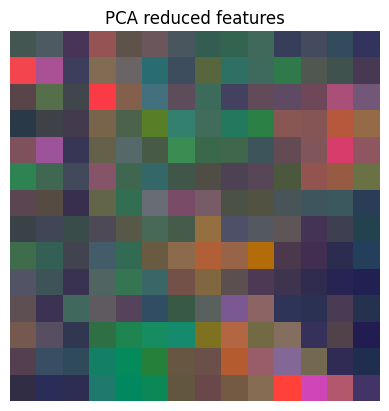

In [28]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)
_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

plots.plot_pca_features(features)

### Classic pipeline

In [29]:
class UnmixingFromFeatures(nn.Module):
    def __init__(self, D, B, c, H=224, alpha=None, kernel_size=1):
        """
        Upsamples low res features then estimates A_hat
        """
        super(UnmixingFromFeatures, self).__init__()
        self.D = D
        self.alpha = alpha
        self.B = B
        self.c = c
        self.H = H
        self.n_features = 1

        # Upsampling features
        self.upsample = nn.Linear(self.alpha**2, self.H**2, bias=False)
        
        # Upsampled features to abundances
        self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, self.n_features, kernel_size=kernel_size)

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09):
        sad = losses.SADLoss()
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Abundances and endmembers regularisation"""

        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        # print(loss_sad, loss_mse, loss_ab, loss_tv_e)
        loss = loss_sad + loss_ab + loss_tv_e + loss_mse

        return loss

    def get_abundances(self, features):

        features_up = self.upsample(features)
        features_up = features_up.view(
            1, self.n_features*self.D, self.H, self.H
        )

        features_up = utils.standardise(features_up)
        A_hat = self.abundance_estimator(features_up)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features):
        A_hat = self.get_abundances(features)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.200, NMSE = 0.198
training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.179, NMSE = 0.164
training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.173, NMSE = 0.208
training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.213, NMSE = 0.219
training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.187, NMSE = 0.181
training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.190, NMSE = 0.218
training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.135, NMSE = 0.192

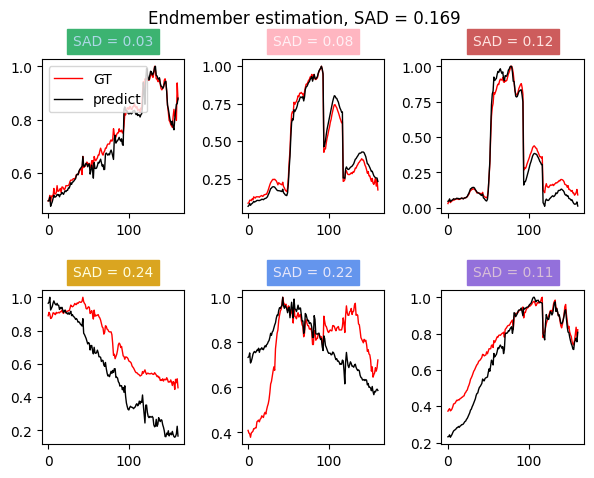

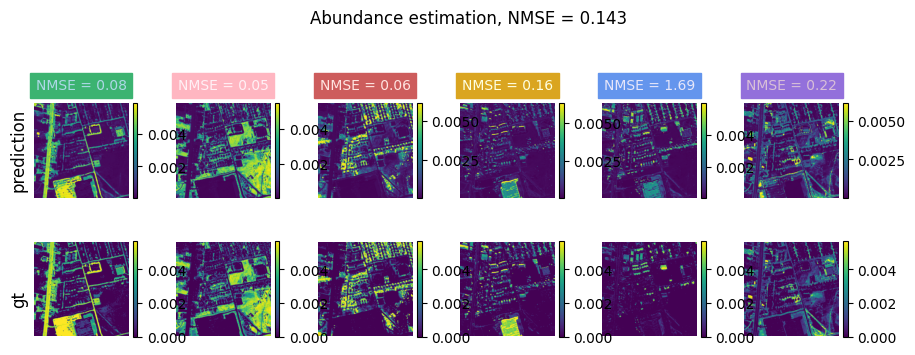

In [31]:
n_xp = 15
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, kernel_size=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y(fm_name, Y, new_H)

            E_hat, A_hat, Y_hat = model(features)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat, W_tv_e=0)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
    
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y(fm_name, Y, new_H, A_init)
        E_hat, A_hat, _ = model(features)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")

### Unmixing LR abundances

In [79]:
class UnmixingFromAbundances(nn.Module):
    def __init__(self, D, B, c, H=224, alpha=None, kernel_size=1):
        """
        Upsamples low res features then estimates A_hat
        """
        super(UnmixingFromAbundances, self).__init__()
        self.D = D
        self.alpha = alpha
        self.B = B
        self.c = c
        self.H = H
        self.n_features = 1

        # Upsampling features
        self.upsample = nn.Linear(self.alpha**2, self.H**2, bias=False)
        
        # Upsampled features to abundances
        self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, self.n_features, kernel_size=kernel_size)

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09):
        sad = losses.SADLoss()
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Abundances and endmembers regularisation"""

        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        loss = loss_sad + loss_ab + loss_tv_e + loss_mse

        return loss

    def get_abundances(self, features):

        features = utils.oneD_to_2d(features).unsqueeze(0)
        A_hat_lr = self.abundance_estimator(features)
        A_hat_lr = self.sum_to_one(A_hat_lr)
        A_hat_lr = A_hat_lr.reshape(1, self.c, self.alpha*self.alpha)
        A_hat = self.upsample(A_hat_lr)
        A_hat = utils.oneD_to_2d(A_hat)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features):
        A_hat = self.get_abundances(features)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

In [80]:
# n_xp = 15
# mses, sads = [], []
# E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

# for i in range(n_xp):
#     print(f"training {i+1}/{n_xp}")

#     model = UnmixingFromAbundances(D=D, alpha=alpha, H=new_H, B=B, c=c, kernel_size=1)
#     model.apply(model.weights_init)
#     model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

#     epochs, lr = 200, 0.002
#     optim_wrapper = dict(
#         optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
#         constructor='LayerDecayOptimizerConstructor_ViT',
#         paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
#     optimizer = build_optim_wrapper(model, optim_wrapper)

#     for _ in range(epochs):

#         for Y, _, _ in loader:
        
#             optimizer.zero_grad()

#             Y = utils.oneD_to_2d(Y).to(dev)

#             _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
#             Y_fm = rsfm.reshape_Y(fm_name, Y, new_H)

#             E_hat, A_hat, Y_hat = model(features)

#             loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#             optimizer.step()
            
#             with torch.no_grad():
#                 constraints = models.weightConstraint()
#                 model.decoder.apply(constraints)
    
#     model.eval()
    
#     with torch.no_grad():
        
#         _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
#         Y_fm, A_init_fm = rsfm.reshape_Y(fm_name, Y, new_H, A_init)
#         E_hat, A_hat, _ = model(features)

#         sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
#         print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
#         mses.append(mse)
#         sads.append(sad)

#     E_hats[i] = E_hat
#     A_hats[i] = A_hat.squeeze(0)

# E_hat_m = torch.mean(E_hats, dim=0)
# A_hat_m = torch.mean(A_hats, dim=0)
# sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
# print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")

### Unmixing LR abundances + consistency

In [81]:
class UnmixingFromAbundancesConsistency(nn.Module):
    def __init__(self, D, B, c, H=224, alpha=None, kernel_size=1):
        """
        Upsamples low res features then estimates A_hat
        """
        super(UnmixingFromAbundancesConsistency, self).__init__()
        self.D = D
        self.alpha = alpha
        self.B = B
        self.c = c
        self.H = H
        self.n_features = 1

        # Upsampling features
        self.upsample = nn.Linear(self.alpha**2, self.H**2, bias=False)
        
        # Upsampled features to abundances
        self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, self.n_features, kernel_size=kernel_size)

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, Y_hat_lr, A_hat, E_hat, alpha, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09, W_down=1e-3):
        sad = losses.SADLoss()
        mse = nn.MSELoss(reduction='sum')
        downsample = nn.AdaptiveAvgPool2d(alpha)
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        Y_lr = downsample(Y_hat)
        loss_re_down = W_down * torch.sum(torch.abs(Y_lr - Y_hat_lr))

        """Abundances and endmembers regularisation"""

        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        loss = loss_sad + loss_ab + loss_tv_e + loss_mse + loss_re_down

        return loss

    def get_abundances(self, features):

        features = utils.oneD_to_2d(features).unsqueeze(0)
        A_hat_lr = self.abundance_estimator(features)
        A_hat_lr = self.sum_to_one(A_hat_lr)
        A_hat = self.upsample(A_hat_lr.flatten(2))
        A_hat = utils.oneD_to_2d(A_hat)
        A_hat = self.sum_to_one(A_hat)

        return A_hat, A_hat_lr
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features):
        A_hat, A_hat_lr = self.get_abundances(features)
        Y_hat = self.decoder(A_hat)
        Y_hat_lr = self.decoder(A_hat_lr)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat, Y_hat_lr

training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.031, NMSE = 0.094
training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.128, NMSE = 0.086
training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.038, NMSE = 0.138
training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.032, NMSE = 0.083
training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.030, NMSE = 0.093
training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.044, NMSE = 0.098
training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.035, NMSE = 0.069

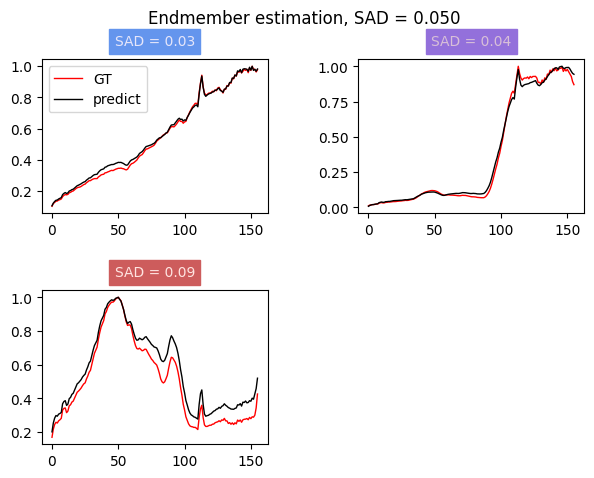

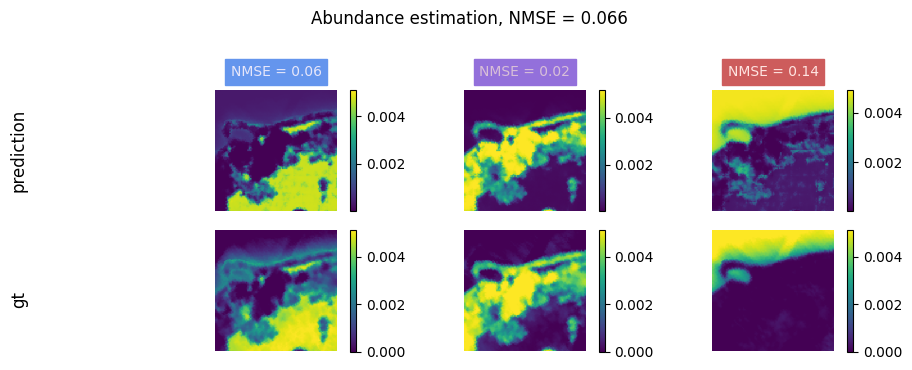

In [82]:
n_xp = 15
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromAbundancesConsistency(D=D, alpha=alpha, H=new_H, B=B, c=c, kernel_size=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y(fm_name, Y, new_H)

            E_hat, A_hat, Y_hat, Y_hat_lr = model(features)

            loss = model.loss(Y_fm, Y_hat, Y_hat_lr, A_hat, E_hat, alpha, W_down=5e-5)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
    
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y(fm_name, Y, new_H, A_init)
        E_hat, A_hat, _, _ = model(features)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")